In [ ]:
import numpy as np
import pandas as pd
import nltk
import random
import matplotlib.pyplot as plt
import SRToolkit.utils as utils

In [31]:
class MCTSNode:
    def __init__(self, state, parent=None, applied_rule=None, depth=0):
        self.state = list(state)
        self.parent = parent
        self.applied_rule = applied_rule
        self.depth = depth
        self.children = []
        self.visits = 0
        self.value = 0.0

    def best_child(self, c_param=1.4):
        log_parent = np.log(self.visits if self.visits > 0 else 1)

        def uct(c):
            if c.visits == 0:
                return float('inf')
            exploitation = c.value / c.visits
            exploration = c_param * np.sqrt(log_parent / c.visits)
            return exploitation + exploration
        
        return max(self.children, key=uct)


class mcts:
    def __init__(self, grammar, first_element, reward, max_rollout_depth=100):
        self.grammar = grammar
        self.first_element = first_element
        self.rules = self.grammar.productions()
        self.max_depth = max_rollout_depth
        self.reward = reward
        self.rollout_results = []

    def get_leftmost_nt(self, state):
        for index, symbol in enumerate(state):
            if isinstance(symbol, nltk.grammar.Nonterminal):
                return index, symbol
        return None, None

    def is_terminal(self, state):
        index, _ = self.get_leftmost_nt(state)
        return index is None

    def search(self, iterations):
        root = MCTSNode([nltk.grammar.Nonterminal(self.first_element)])
        for i in range(iterations):
            node = self.tree_policy(root)
            reward = self.simulate(node)
            self.backpropagate(node, reward)
    
        return self.rollout_results


    def tree_policy(self, node):
        #TODO morda dodati epsilon greedy strategijo 
        while not self.is_terminal(node.state):
            index, nt = self.get_leftmost_nt(node.state)
            applicable = [r for r in self.rules if r.lhs() == nt]

            if len(node.children) < len(applicable):
                return self.expand(node,applicable,index)
            
            node = node.best_child()
        return node
    
    def expand(self, node, applicable, index):
        tried = [c.applied_rule for c in node.children]
        
        for prod in applicable:
            if prod not in tried:
                new_state = list(node.state)
                new_state[index:index+1] = list(prod.rhs())
                new_node = MCTSNode(new_state, node, prod, node.depth + 1)
                node.children.append(new_node)
                return new_node
        return node
    

    def simulate(self, node):

        current_state = list(node.state)
        depth = node.depth

        while not self.is_terminal(current_state) and depth < self.max_depth:
  
            index, nt = self.get_leftmost_nt(current_state)
            rules = [r for r in self.rules if r.lhs() == nt]
            probs = [r.prob() for r in rules]
            selected = random.choices(rules, weights=probs, k=1)[0]
            current_state[index:index+1] = list(selected.rhs())
            depth += 1
        

        if not self.is_terminal(current_state):
            print("warning: reached max depth without terminal state")
            return 0.0

        state_string = "".join(str(t) for t in current_state)
        reward = self.reward(state_string)
        self.rollout_results.append((state_string, reward))
        return reward

    def backpropagate(self, node, reward):
        while node is not None:
            node.visits += 1
            node.value += reward
            node = node.parent


In [32]:
def mc_search(grammar, iterations, utility):
    results = []
    for i in range(iterations):
        state = utils.generate_from_pcfg(grammar)
        reward = utility(state)
        state_string = "".join(str(t) for t in state)
        results.append((state_string, reward))
    return results

In [33]:
# za zacetek vzamemo 3

p_a = 0.1
p_b = 0.9
p_c = 0.9

grammar = f"""
    E -> A B C [1.0]
    
    A -> A'a' [{p_a}]
    A -> 'a'   [{1 - p_a}]
    
    B -> B'b' [{p_b}]
    B -> 'b'   [{1 - p_b}]
    
    C -> C'c' [{p_c}]
    C -> 'c'   [{1 - p_c}]
"""

def gini_impurity(expr):
    return 1 - sum(expr.count(c)**2 for c in set(expr))/len(expr)**2

nltk_grammar = nltk.grammar.PCFG.fromstring(grammar)
mcts = mcts(nltk_grammar, first_element="E", reward=gini_impurity, max_rollout_depth=100)
results_mcts = mcts.search(1000)
results_mc = mc_search(grammar, 1000, gini_impurity)
results_mcts


[('abbcccc', 0.5714285714285714),
 ('aabbbbbbbbbbbbcccccccc', 0.5619834710743802),
 ('abbbbbbbbbbbccc', 0.4177777777777778),
 ('aaabbbbbbbbbbbbbbbbbbcccc', 0.4416),
 ('abbbcccc', 0.59375),
 ('abcc', 0.625),
 ('aabbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbc', 0.12641975308641973),
 ('abccc', 0.56),
 ('abbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbc', 0.11245674740484424),
 ('aaaabbbbbbbbbbbbbbc', 0.40997229916897504),
 ('aabbbbbbbbbbbbbbbbbbbbbbbbbbbbcc', 0.2265625),
 ('abc', 0.6666666666666667),
 ('abc', 0.6666666666666667),
 ('abbccc', 0.6111111111111112),
 ('aaabbbbccccc', 0.6527777777777778),
 ('abccccccc', 0.37037037037037035),
 ('aaabbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbccccccccccccccccccccccccccccccccccccccccccccccc',
  0.5248783126014062),
 ('aabccc', 0.6111111111111112),
 ('abbccc', 0.6111111111111112),
 ('aaaaabbbbbbbbbbbbbbbbbbbbbbbcccccccccccccccccccc', 0.5859375),
 ('abbc', 0.625),
 ('aabcccc', 0.5714285714285714),
 ('abc', 0.6666666666666667),
 ('abbbbbbbbbbbbbbbbbcccccccccccc', 0.5177777

Izračunamo še  ``` drseče povprečje ```, da vidimo, koliko se model sploh uči.

In [34]:
def plot_progress(results, name, window = 20):

    scores = [item[1] for item in results]
    max_scores = np.maximum.accumulate(scores)

    moving_avg = np.convolve(scores, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(10, 5))
    
    plt.scatter(range(len(scores)), scores, color='black', alpha=0.5, s=5, label='nagradna funkcija iteracije')
    plt.plot(range(len(max_scores)), max_scores, color='blue', linewidth=2, label='nagradna funkcija najboljšega rezultata')
    plt.plot(range(window-1, len(scores)), moving_avg, color='red', label='moving average')
    
    plt.title(name)
    plt.xlabel('Število iteracij')
    plt.ylabel('Funkcija nagrade')
    plt.legend()
    
    plt.show()


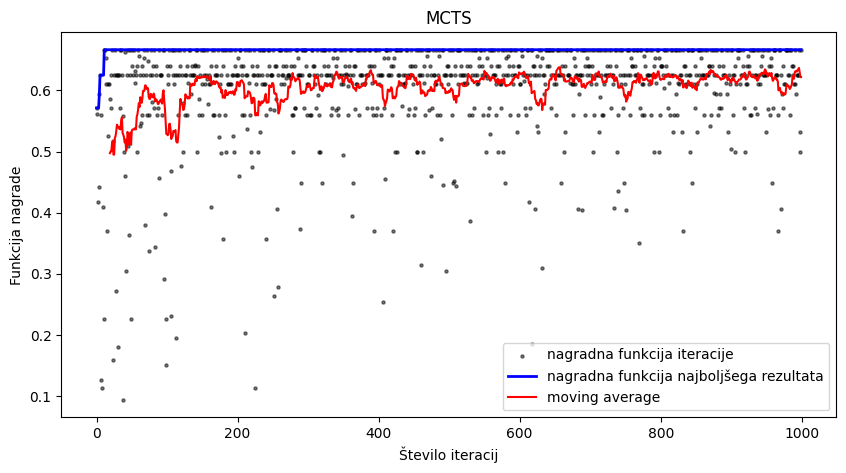

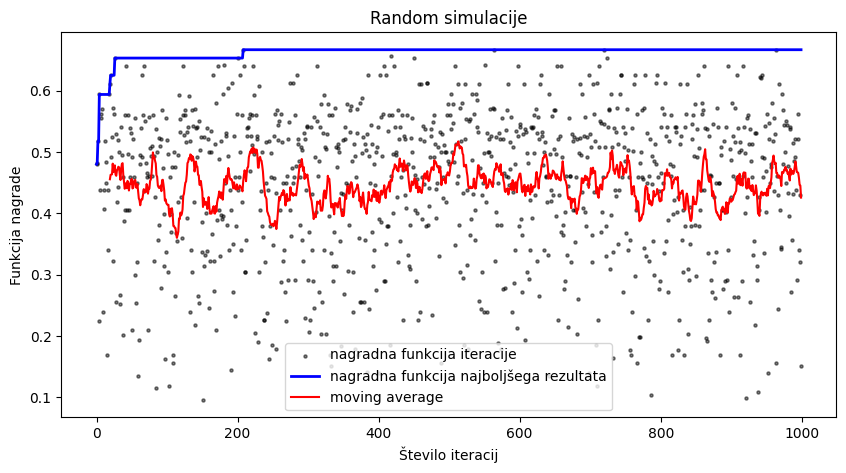

In [35]:
plot_progress(results_mcts, name="MCTS")
plot_progress(results_mc, name="Random simulacije")

Poizkus implementacije za enačbe:

In [195]:
class MCTSNode:
    def __init__(self, state, parent=None, applied_rule=None, depth=0):
        self.state = list(state)
        self.parent = parent
        self.applied_rule = applied_rule
        self.depth = depth
        self.children = []
        self.visits = 0
        self.value = 0.0
        if parent and applied_rule:
            self.log_prob = parent.log_prob + np.log(applied_rule.prob())
        else:
            self.log_prob = 0.0

    def best_child(self, c_param=1.4):
        log_parent = np.log(self.visits if self.visits > 0 else 1)

        def uct(c):
            if c.visits == 0:
                return float('inf')
            exploitation = c.value / c.visits
            exploration = c_param * np.sqrt(log_parent / c.visits)
            return exploitation + exploration
        
        return max(self.children, key=uct)


class GRAMS:
    def __init__(self, grammar, first_element, reward, evaluator, error = 1e-7, max_rollout_depth=100, c_param=1.4):
        self.grammar = grammar
        self.first_element = first_element
        self.reward = reward
        self.evaluator = evaluator
        self.rules = self.grammar.productions()
        self.error = error
        self.max_depth = max_rollout_depth
        self.best_model = None
        self.min_rmse = float('inf')
        self.history = []
        self.n_points = self.evaluator.X.shape[0]
        self.c_param = c_param

    def get_leftmost_nt(self, state):
        for index, token in enumerate(state):
            if isinstance(token, nltk.grammar.Nonterminal):
                return index, token
        return None, None
    
    def is_terminal(self, state):
        index, _ = self.get_leftmost_nt(state)
        return index is None    
    
    def search(self, iterations):
        root = MCTSNode([nltk.grammar.Nonterminal(self.first_element)])
        # root.log_prob = 0.0

        for i in range(iterations):
            node = self.tree_policy(root)
            reward = self.simulate(node)
            self.backpropagate(node, reward)

            if self.min_rmse <= self.error:
                print(f"Stopping early at iteration {i} with RMSE {self.min_rmse}")
                return self.history, self.best_model, self.min_rmse
    
        return self.history, self.best_model, self.min_rmse

    def tree_policy(self, node):
        while not self.is_terminal(node.state):
            index, nt = self.get_leftmost_nt(node.state)
            applicable = [r for r in self.rules if r.lhs() == nt]

            if len(node.children) < len(applicable):
                return self.expand(node,applicable,index)
            
            node = node.best_child(c_param=self.c_param)
        return node
    
    def expand(self, node, applicable, index):
        tried = [c.applied_rule for c in node.children]
        
        for prod in applicable:
            if prod not in tried:
                new_state = list(node.state)
                new_state[index:index+1] = list(prod.rhs())
                new_node = MCTSNode(new_state, node, prod, node.depth + 1)
                node.children.append(new_node)
                return new_node
        return node
    
    def simulate(self, node):
        current_state = list(node.state)
        depth = node.depth
        rollout_log_prob = node.log_prob

        while not self.is_terminal(current_state) and depth < self.max_depth:
            index, nt = self.get_leftmost_nt(current_state)
            rules = [r for r in self.rules if r.lhs() == nt]
            probs = [r.prob() for r in rules]
            selected = random.choices(rules, weights=probs, k=1)[0]
            rollout_log_prob += np.log(selected.prob())
            current_state[index:index+1] = list(selected.rhs())
            depth += 1
        
        if not self.is_terminal(current_state):
            print("Warning: reached max depth without terminal state")
            return 0.0

        tokens = [str(t) for t in current_state]
        state_str = "".join(tokens)

        
        rmse = self.evaluator.evaluate_expr(tokens)
        if np.isnan(rmse):
            return 0.0
        model_res = self.evaluator.models[state_str]
        num_params = len(getattr(model_res, 'parameters', []))

        current_reward = self.reward(
            rmse=rmse,
            k=num_params +1, 
            n=self.n_points, 
            log_prob=rollout_log_prob
        )
    
        if rmse < self.min_rmse:
            self.min_rmse = rmse
            self.best_model = state_str

        self.history.append((state_str, rmse, current_reward))
        return current_reward


    def backpropagate(self, node, reward):
        while node is not None:
            node.visits += 1
            node.value += reward
            node = node.parent

    def standard_mc(self, node, iterations):
        total_reward = 0.0
        for _ in range(iterations):
            reward = self.simulate(node)
            total_reward += reward

        average_reward = total_reward / iterations
        return average_reward


In [37]:
def test_mcts():
    pass

In [196]:
from SRToolkit.evaluation import SR_evaluator
from SRToolkit.utils.symbol_library import SymbolLibrary

variables = ["X_0", "X_1"]
grammar = "E -> E '+' F [0.2] | E '-' F [0.2] | F [0.6]\n"
grammar += "F -> F '*' T [0.2] | F '/' T [0.2] | T [0.6]\n"
grammar += "T -> '(' E ')' [0.2] | V [0.6] | 'sin' '(' E ')' [0.2]\n"
grammar += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])
nltk_grammar = nltk.grammar.PCFG.fromstring(grammar)
lib = SymbolLibrary.default_symbols(num_variables=len(variables))

N = 100
x_train = np.random.uniform(-5, 5, (N, len(variables)))
y_train = x_train[:, 1] / x_train[:, 0]

# preprosta funkcija nagrade za testiranje (samo z napako RMSE)
def reward_rmse(*, rmse, **kwargs):
    return 1/(rmse + 1e-6)


eval = SR_evaluator(X=x_train, y=y_train, symbol_library=lib)
mcts = GRAMS(nltk_grammar, 'E', reward_rmse, eval, error=1e-9, max_rollout_depth=500)
results, best_model, best_rmse = mcts.search(1000)
if best_model:
    print(f"Best model: {best_model}")

Stopping early at iteration 74 with RMSE 0.0
Best model: X_1/X_0


In [197]:
variables = ["X_0", "X_1", "X_2"]
grammar = "E -> E '+' T [0.4] | T [0.6]\n"
grammar += "T -> 'C' '*' V [0.7] | V [0.3]\n"
grammar += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])
nltk_grammar = nltk.grammar.PCFG.fromstring(grammar)
lib = SymbolLibrary.default_symbols(num_variables=len(variables))


N = 100
x_train = np.random.uniform(-5, 5, (N, len(variables)))
y_train = 2.5 * x_train[:, 0] -2 * x_train[:, 1] + 4 * x_train[:, 2]

eval = SR_evaluator(X=x_train, y=y_train, symbol_library=lib)
mcts = GRAMS(nltk_grammar, 'E', reward_rmse, eval, error=1e-9, max_rollout_depth=100)
results, best_model, best_rmse = mcts.search(1000)
if best_model:
    print(f"Best model: {best_model}")

Best model: C*X_2+C*X_0+X_1+X_1+X_1+C*X_2+C*X_0+C*X_1


In [199]:
variables = ["X_0", "X_1", "X_2", "X_3", "X_4", "X_5"]
grammar = "E -> E '+' F [0.2] | E '-' F [0.2] | F [0.6]\n"
grammar += "F -> F '*' T [0.2] | F '/' T [0.2] | T [0.6]\n"
grammar += "T -> '(' E ')' [0.2] | V [0.6] | 'sin' '(' E ')' [0.2]\n"
grammar += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])
nltk_grammar = nltk.grammar.PCFG.fromstring(grammar)
lib = SymbolLibrary.default_symbols(num_variables=len(variables))

N = 100
x_train = np.random.uniform(-5, 5, (N, len(variables)))
y_train = x_train[:, 0] - 3*x_train[:, 1] - x_train[:, 2] - x_train[:, 3]

eval = SR_evaluator(X=x_train, y=y_train, symbol_library=lib)
mcts = GRAMS(nltk_grammar, 'E', reward_rmse, eval, error=1e-9, max_rollout_depth=100)
results, best_model, best_rmse = mcts.search(1000)
if best_model:
    print(f"Best model: {best_model}")

Best model: X_0+X_4-X_1+(X_3)-X_2+sin(X_5)-X_4


In [42]:
def reward_new(rmse, k,n,log_prob):
    log_posterior = - k/2 * np.log(n) + log_prob - n/2*np.log(2*np.pi) -n/2 - n*np.log(rmse)
    return 1/(1+abs(log_posterior))

In [205]:
mcts = GRAMS(nltk_grammar, 'E', reward_new, eval, error=1e-9, max_rollout_depth=100)
results, best_model, best_rmse = mcts.search(10000)
if best_model:
    print(f"Best model: {best_model}")
    print(f"Best RMSE: {best_rmse}")

Best model: (X_0)/X_0-X_0/X_0-(X_1)-X_1
Best RMSE: 5.478071064615894


In [44]:
def plot_progress_rmse(results, name, window=20):

    rmses = np.array([item[1] for item in results], dtype=float)
    best_rmse = np.minimum.accumulate(rmses)

    moving_avg = np.convolve(rmses, np.ones(window)/window, mode='valid')
    
    plt.figure(figsize=(10, 5))

    plt.scatter(range(len(rmses)), rmses, color='black', alpha=0.5, s=5, label='RMSE v iteraciji')
    plt.plot(range(len(best_rmse)), best_rmse, color='blue', linewidth=2, label='najmanjši RMSE do zdaj')
    plt.plot(range(window-1, len(rmses)), moving_avg, color='red', label=f'moving average')

    plt.title(name)
    plt.xlabel('Število iteracij')
    plt.ylabel('RMSE')
    plt.legend()

    plt.show()


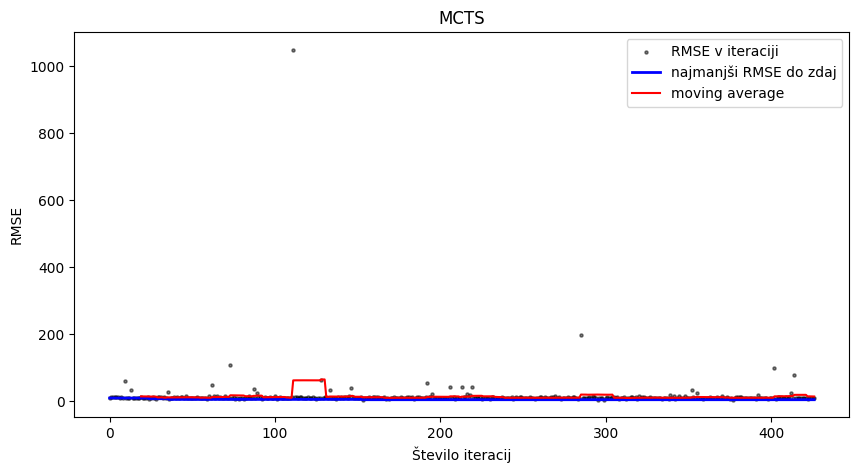

In [45]:
plot_progress_rmse(results, name="MCTS")